In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\wpqlc\OneDrive\바탕 화면\ESG 데이터\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


In [4]:
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [10]:
df = pd.read_csv("data/2024_corp_emission.csv", encoding="cp949")

In [11]:
print(df.shape)
print(df.columns.tolist())

(778, 10)
['NO', '업체명', '대상년도', '지정구분', '부문', '계획업종', '온실가스배출량', '에너지사용량', '검증수행기관', '중소기업여부']


In [12]:
df.head()

,NO,업체명,대상년도,지정구분,부문,계획업종,온실가스배출량,에너지사용량,검증수행기관,중소기업여부
0,1,베올리아워터코리아대산(주),2024,사업장,공공·기타,수도업,"89,082","1,859",(주)한국경영인증원,N
1,2,네이처이앤티(주),2024,업체,폐기물,폐기물처리업,"198,107",439,(주)비에스아이그룹코리아,Y
2,3,씨이케이주식회사,2024,업체,폐기물,폐기물처리업,"226,301","1,308",(재)한국품질재단,N
3,4,대일개발주식회사,2024,사업장,폐기물,폐기물처리업,"55,847",155,로이드인증원㈜,Y
4,5,전주시,2024,업체,폐기물,폐기물처리업,"168,919","1,777",㈜한국품질보증원,N


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   NO       778 non-null    int64
 1   업체명      778 non-null    str  
 2   대상년도     778 non-null    int64
 3   지정구분     778 non-null    str  
 4   부문       778 non-null    str  
 5   계획업종     778 non-null    str  
 6   온실가스배출량  778 non-null    str  
 7   에너지사용량   778 non-null    str  
 8   검증수행기관   777 non-null    str  
 9   중소기업여부   778 non-null    str  
dtypes: int64(2), str(8)
memory usage: 60.9 KB


In [14]:
df.describe(include='all')

,NO,업체명,대상년도,지정구분,부문,계획업종,온실가스배출량,에너지사용량,검증수행기관,중소기업여부
count,778.000000,778,778.0,778,778,778,778,778,777,778
unique,NaN,777,NaN,2,6,70,776,693,13,2
top,NaN,경원여객자동차(주),NaN,사업장,산업,폐기물처리업,"58,486",0,한국표준협회,N
freq,NaN,2,NaN,444,481,110,2,6,203,652
mean,389.500000,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,224.733546,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,195.250000,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,389.500000,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,583.750000,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.isnull().sum()

NO         0
업체명        0
대상년도       0
지정구분       0
부문         0
계획업종       0
온실가스배출량    0
에너지사용량     0
검증수행기관     1
중소기업여부     0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
for col in ['대상년도', '지정구분', '부문', '계획업종', '검증수행기관', '중소기업여부']:
    print(f'\n[{col}]')
    print(df[col].value_counts(dropna=False))


[대상년도]
대상년도
2024    778
Name: count, dtype: int64

[지정구분]
지정구분
사업장    444
업체     334
Name: count, dtype: int64

[부문]
부문
산업       481
폐기물      121
수송        67
전환        65
건물        42
공공·기타      2
Name: count, dtype: int64

[계획업종]
계획업종
폐기물처리업             110
기초화학물질제조업           66
1차철강제조업             43
증기,냉ㆍ온수및공기조절공급업     42
펄프,종이및판지제조업         40
                  ... 
무기및총포탄제조업            1
항공기,우주선및부품제조업        1
유원지및기타오락관련서비스업       1
건물건설업                1
보관및창고업               1
Name: count, Length: 70, dtype: int64

[검증수행기관]
검증수행기관
한국표준협회                203
(주)한국경영인증원            162
(재)한국품질재단             125
㈜한국품질보증원               70
㈜디엔브이비즈니스어슈어런스코리아      54
로이드인증원㈜                51
(주)비에스아이그룹코리아          25
대일이엔씨기술(주)             25
(재)한국화학융합시험연구원         15
한국가스안전공사               14
(주)신화엔지니어링종합건축사사무소     14
한국생산성본부인증원(주)          10
지속가능인증원주식회사             9
NaN                     1
Name: count, dtype: int64

[중소기업여부]
중소기업여부
N    652
Y    126
Name: count, dtype: int64


In [18]:
print(df['온실가스배출량'].head(10))
print(df['에너지사용량'].head(10))

0     89,082
1    198,107
2    226,301
3     55,847
4    168,919
5     53,883
6    191,023
7     94,700
8     64,339
9     51,879
Name: 온실가스배출량, dtype: str
0    1,859
1      439
2    1,308
3      155
4    1,777
5      608
6    2,010
7      841
8       70
9      330
Name: 에너지사용량, dtype: str


In [19]:
print(df['온실가스배출량'].tail(10))
print(df['에너지사용량'].tail(10))

768    22,940
769    57,667
770    32,691
771    20,832
772    23,918
773    27,838
774    23,408
775    60,296
776    36,958
777    70,239
Name: 온실가스배출량, dtype: str
768      333
769      842
770      485
771      296
772      400
773      436
774      340
775    1,168
776    1,729
777      969
Name: 에너지사용량, dtype: str


In [20]:
df['온실가스배출량'] = (
    df['온실가스배출량']
    .str.replace(',', '', regex=False)
    .astype(int)
)

df['에너지사용량'] = (
    df['에너지사용량']
    .str.replace(',', '', regex=False)
    .astype(int)
)

ValueError: invalid literal for int() with base 10: '*****'

In [21]:
print((df['온실가스배출량'] == '*****').sum())
print((df['에너지사용량'] == '*****').sum())

1
1


In [22]:
df.loc[
    (df['온실가스배출량'] == '*****') |
    (df['에너지사용량'] == '*****'),
    ['업체명', '대상년도', '온실가스배출량', '에너지사용량']
]

,업체명,대상년도,온실가스배출량,에너지사용량
453,대구텍유한책임회사,2024,*****,*****


결측값 (****) NaN으로 교체 

In [23]:
df['온실가스배출량'] = pd.to_numeric(
    df['온실가스배출량'].str.replace(',', '', regex=False),
    errors='coerce'
)

df['에너지사용량'] = pd.to_numeric(
    df['에너지사용량'].str.replace(',', '', regex=False),
    errors='coerce'
)

In [24]:
df[['온실가스배출량', '에너지사용량']].dtypes

온실가스배출량    float64
에너지사용량     float64
dtype: object

In [25]:
df[['온실가스배출량', '에너지사용량']].isnull().sum()

온실가스배출량    1
에너지사용량     1
dtype: int64

In [28]:
df[['온실가스배출량', '에너지사용량']].dtypes

온실가스배출량    float64
에너지사용량     float64
dtype: object

In [29]:
df.isnull().sum()

NO         0
업체명        0
대상년도       0
지정구분       0
부문         0
계획업종       0
온실가스배출량    1
에너지사용량     1
검증수행기관     1
중소기업여부     0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
categorical_cols = [
    '대상년도',
    '지정구분',
    '부문',
    '계획업종',
    '검증수행기관',
    '중소기업여부'
]

for col in categorical_cols:
    print(f'\n===== {col} =====')
    print(df[col].value_counts(dropna=False))


===== 대상년도 =====
대상년도
2024    778
Name: count, dtype: int64

===== 지정구분 =====
지정구분
사업장    444
업체     334
Name: count, dtype: int64

===== 부문 =====
부문
산업       481
폐기물      121
수송        67
전환        65
건물        42
공공·기타      2
Name: count, dtype: int64

===== 계획업종 =====
계획업종
폐기물처리업             110
기초화학물질제조업           66
1차철강제조업             43
증기,냉ㆍ온수및공기조절공급업     42
펄프,종이및판지제조업         40
                  ... 
무기및총포탄제조업            1
항공기,우주선및부품제조업        1
유원지및기타오락관련서비스업       1
건물건설업                1
보관및창고업               1
Name: count, Length: 70, dtype: int64

===== 검증수행기관 =====
검증수행기관
한국표준협회                203
(주)한국경영인증원            162
(재)한국품질재단             125
㈜한국품질보증원               70
㈜디엔브이비즈니스어슈어런스코리아      54
로이드인증원㈜                51
(주)비에스아이그룹코리아          25
대일이엔씨기술(주)             25
(재)한국화학융합시험연구원         15
한국가스안전공사               14
(주)신화엔지니어링종합건축사사무소     14
한국생산성본부인증원(주)          10
지속가능인증원주식회사             9
NaN                     1
Name: count, dtype: int64

===== 중소기업여부 

In [34]:
df[['온실가스배출량', '에너지사용량']].describe()

,온실가스배출량,에너지사용량
count,7.770000e+02,777.000000
mean,7.076955e+05,9179.019305
std,3.694796e+06,35993.834656
min,0.000000e+00,0.000000
25%,4.111300e+04,583.000000
50%,8.714400e+04,1299.000000
75%,2.237120e+05,3447.000000
max,7.106514e+07,395116.000000


평균과 중앙값 차이가 매우 크다.

온실가스 배출량 분포 시각화

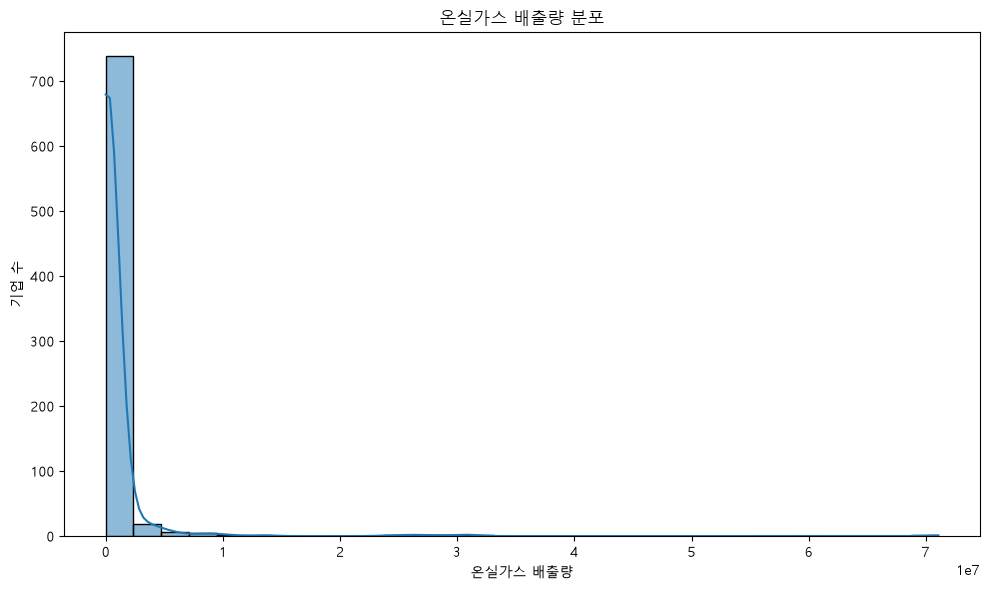

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='온실가스배출량',
    bins=30,
    kde=True
)

plt.title('온실가스 배출량 분포')
plt.xlabel('온실가스 배출량')
plt.ylabel('기업 수')

plt.tight_layout()
plt.show()

위 이상치 너무 심함 

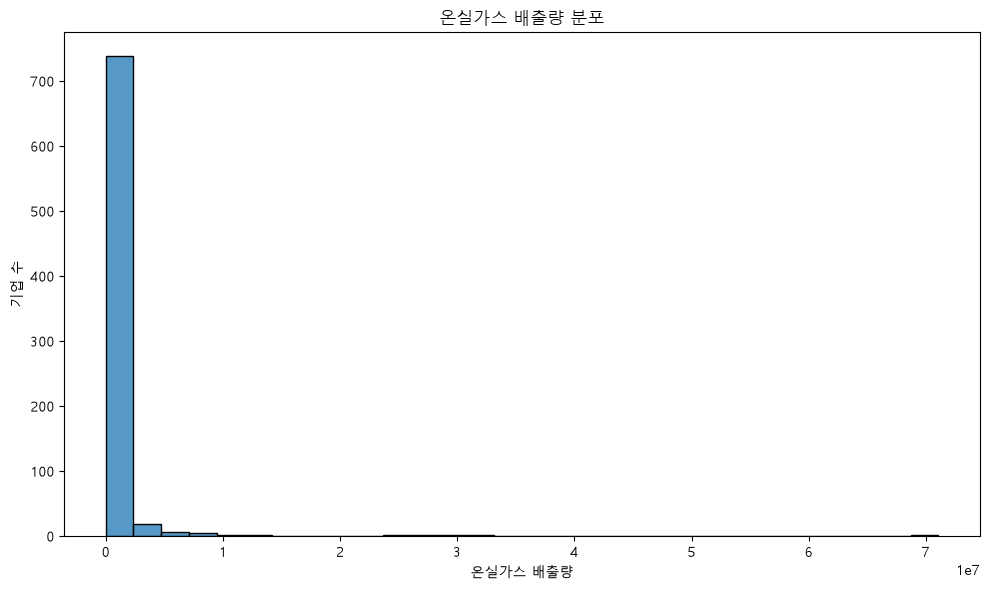

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['온실가스배출량'].dropna(),
    bins=30
)

plt.title('온실가스 배출량 분포')
plt.xlabel('온실가스 배출량')
plt.ylabel('기업 수')

plt.tight_layout()
plt.show()

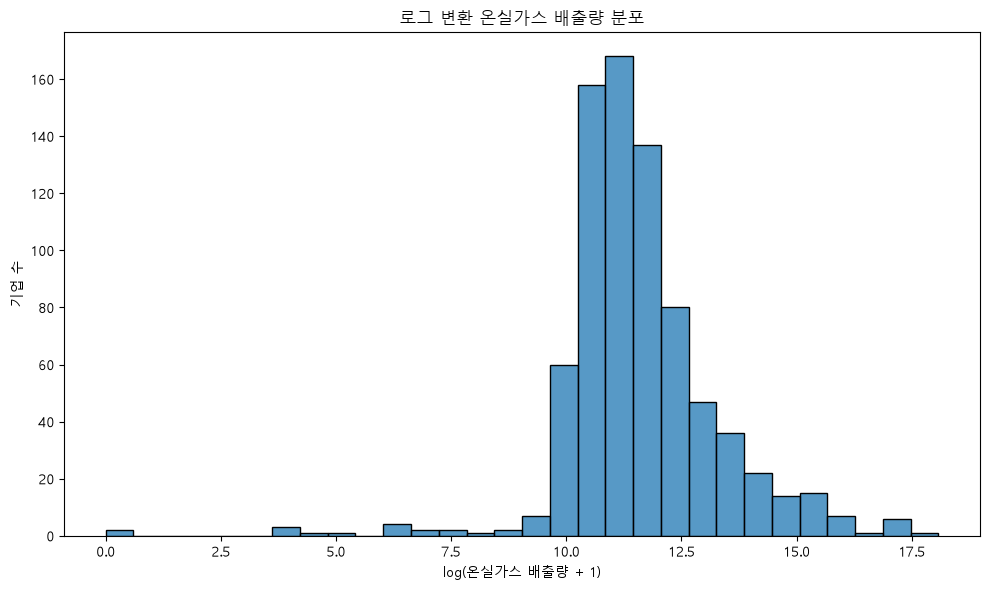

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(df['온실가스배출량'].dropna()),
    bins=30
)

plt.title('로그 변환 온실가스 배출량 분포')
plt.xlabel('log(온실가스 배출량 + 1)')
plt.ylabel('기업 수')

plt.tight_layout()
plt.show()

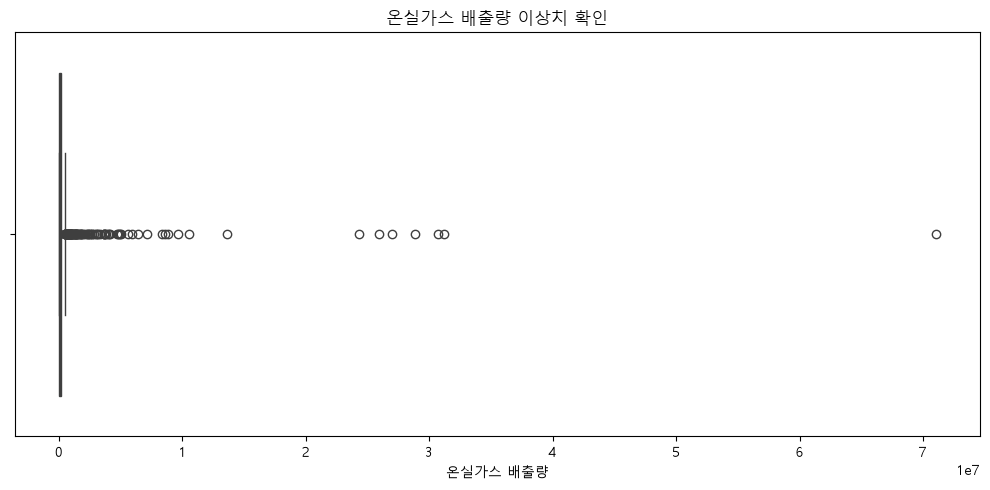

In [36]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df['온실가스배출량']
)

plt.title('온실가스 배출량 이상치 확인')
plt.xlabel('온실가스 배출량')

plt.tight_layout()
plt.show()

In [37]:
top_emitter = df.sort_values(
    '온실가스배출량',
    ascending=False
)

top_emitter[
    ['업체명', '대상년도', '계획업종', '온실가스배출량', '에너지사용량']
].head(20)

,업체명,대상년도,계획업종,온실가스배출량,에너지사용량
423,주식회사포스코,2024,1차철강제조업,71065143.0,377245.0
577,한국중부발전,2024,전기업,31166623.0,395116.0
571,한국남동발전,2024,전기업,30710313.0,372124.0
403,현대제철주식회사,2024,1차철강제조업,28817883.0,159666.0
574,한국서부발전,2024,전기업,26963939.0,333064.0
573,한국동서발전주식회사,2024,전기업,25977192.0,319409.0
572,한국남부발전주식회사,2024,전기업,24346135.0,321468.0
476,삼성전자주식회사,2024,반도체제조업,13594735.0,258102.0
364,쌍용씨앤이(주),2024,"시멘트,석회,플라스터및그외제품제조업",10574492.0,62316.0
232,S-Oil(주),2024,석유정제품제조업,9632037.0,127580.0


업종별 분류

In [38]:
industry_emission = (
    df.groupby('계획업종')['온실가스배출량']
      .agg(['count', 'mean', 'median', 'sum'])
      .sort_values('sum', ascending=False)
)

industry_emission

,count,mean,median,sum
계획업종,,,,
전기업,21,8.529523e+06,2843691.0,179119982.0
1차철강제조업,43,2.497441e+06,90621.0,107389951.0
기초화학물질제조업,66,7.260711e+05,254394.5,47920692.0
"시멘트,석회,플라스터및그외제품제조업",32,1.189208e+06,145373.0,38054643.0
석유정제품제조업,6,5.593483e+06,6787579.5,33560900.0
...,...,...,...,...
"섬유제품염색,정리및마무리가공업",2,2.880700e+04,28807.0,57614.0
방적및가공사제조업,1,5.072700e+04,50727.0,50727.0
보관및창고업,1,3.695800e+04,36958.0,36958.0


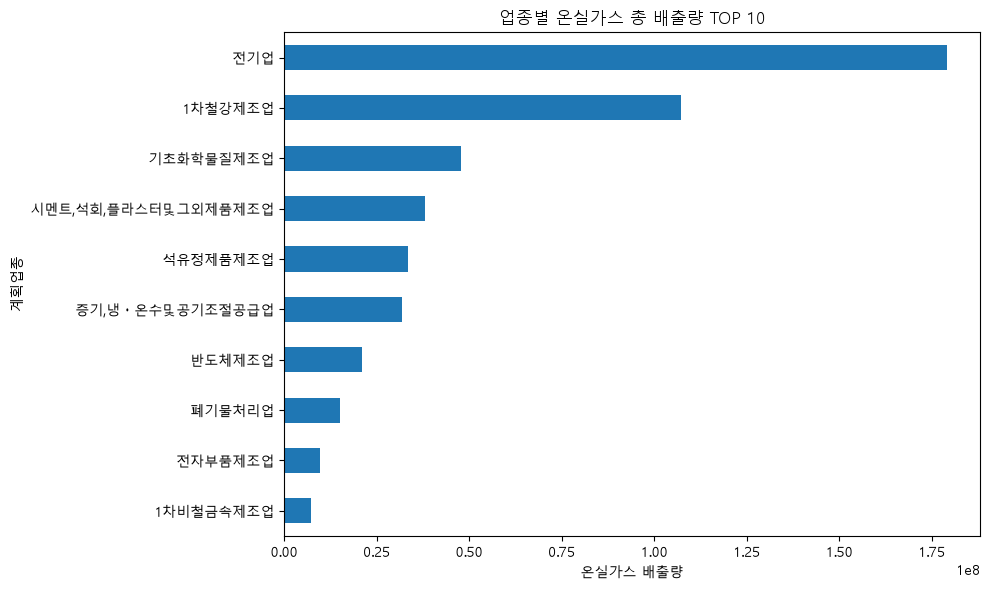

In [39]:
industry_emission.head(10)['sum'].sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('업종별 온실가스 총 배출량 TOP 10')
plt.xlabel('온실가스 배출량')
plt.ylabel('계획업종')

plt.tight_layout()
plt.show()

In [40]:
df['중소기업여부'].value_counts(dropna=False)

중소기업여부
N    652
Y    126
Name: count, dtype: int64

In [41]:
df.groupby('중소기업여부')['온실가스배출량'].agg(
    ['count', 'mean', 'median', 'sum']
)

,count,mean,median,sum
중소기업여부,,,,
N,651,829652.877112,98202.0,540104023.0
Y,126,77582.396825,47567.0,9775382.0


In [ ]:
에너지 사용량, 온실가스 배출량 상관관계 

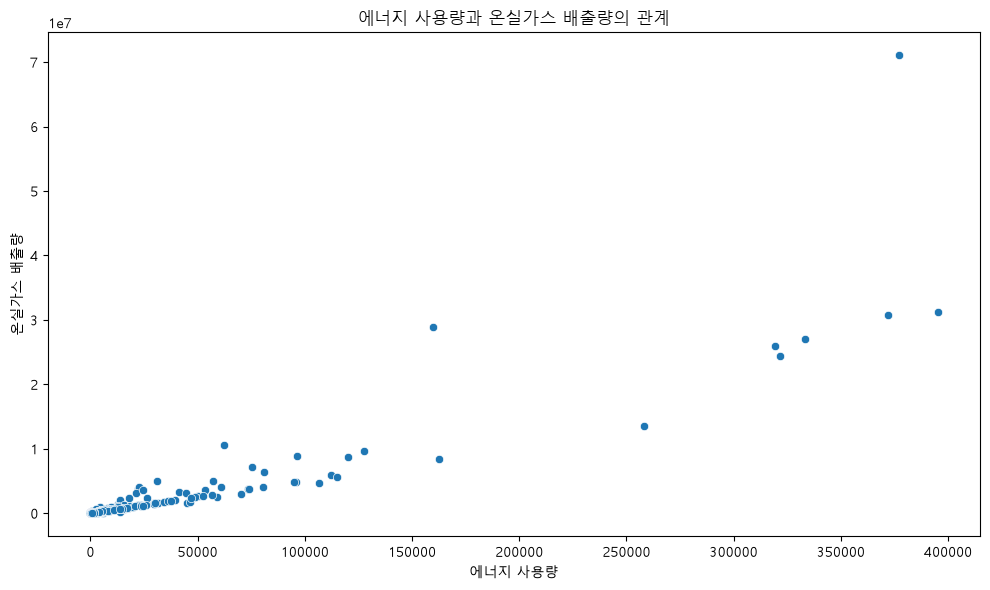

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='에너지사용량',
    y='온실가스배출량'
)

plt.title('에너지 사용량과 온실가스 배출량의 관계')
plt.xlabel('에너지 사용량')
plt.ylabel('온실가스 배출량')

plt.tight_layout()
plt.show()

In [43]:
df[['온실가스배출량', '에너지사용량']].corr()

,온실가스배출량,에너지사용량
온실가스배출량,1.000000,0.899006
에너지사용량,0.899006,1.000000


In [46]:
industry_count = df['계획업종'].value_counts()

industry_count

계획업종
폐기물처리업             110
기초화학물질제조업           66
1차철강제조업             43
증기,냉ㆍ온수및공기조절공급업     42
펄프,종이및판지제조업         40
                  ... 
무기및총포탄제조업            1
항공기,우주선및부품제조업        1
유원지및기타오락관련서비스업       1
건물건설업                1
보관및창고업               1
Name: count, Length: 70, dtype: int64

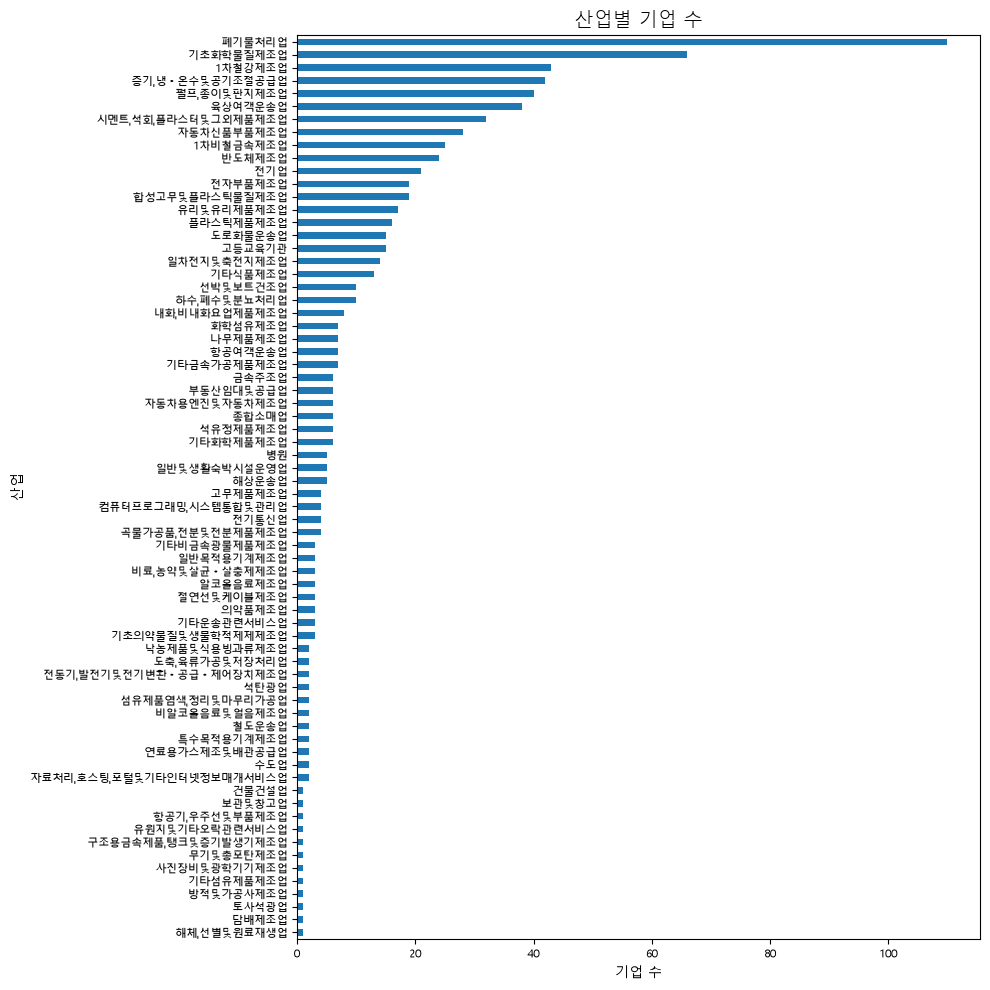

In [48]:
plt.figure(figsize=(10, 10))

industry_count.sort_values().plot(
    kind='barh',
    fontsize=8
)

plt.title('산업별 기업 수', fontsize=14)
plt.xlabel('기업 수', fontsize=10)
plt.ylabel('산업', fontsize=10)

plt.tight_layout()
plt.show()

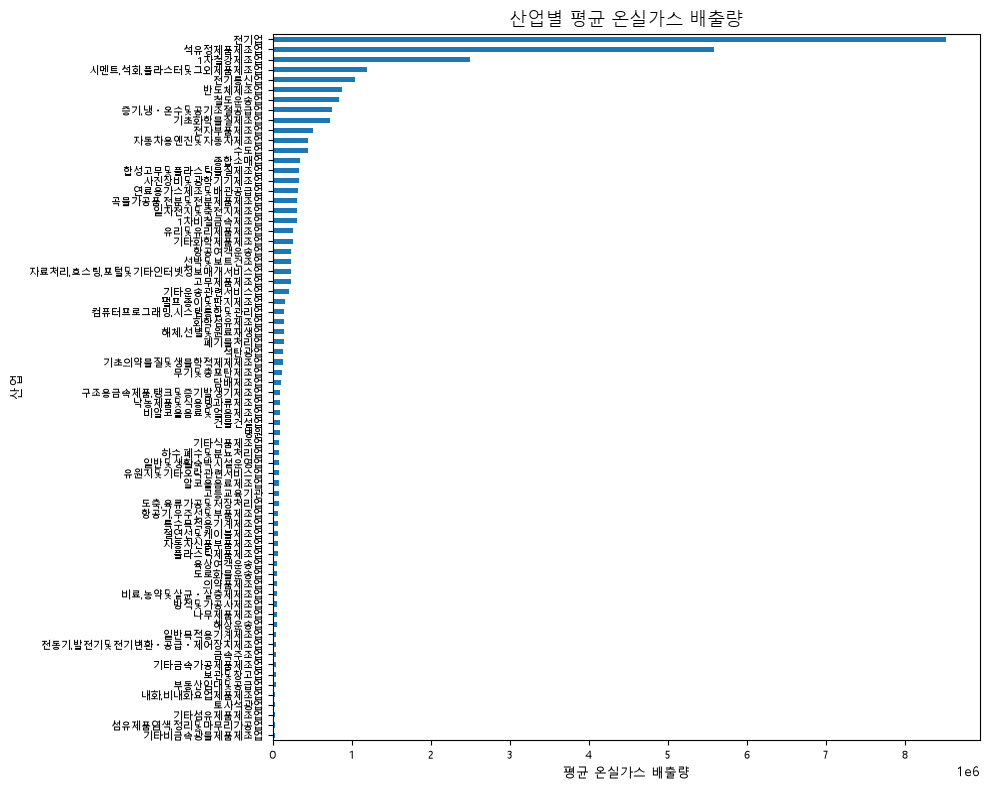

In [50]:
industry_mean = (
    df.groupby('계획업종')['온실가스배출량']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

industry_mean.sort_values().plot(
    kind='barh'
)

plt.title('산업별 평균 온실가스 배출량', fontsize=13)
plt.xlabel('평균 온실가스 배출량', fontsize=9)
plt.ylabel('산업', fontsize=9)

plt.xticks(fontsize=8)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

사업장/업체 구분


In [52]:
df['지정구분'].value_counts()

지정구분
사업장    444
업체     334
Name: count, dtype: int64

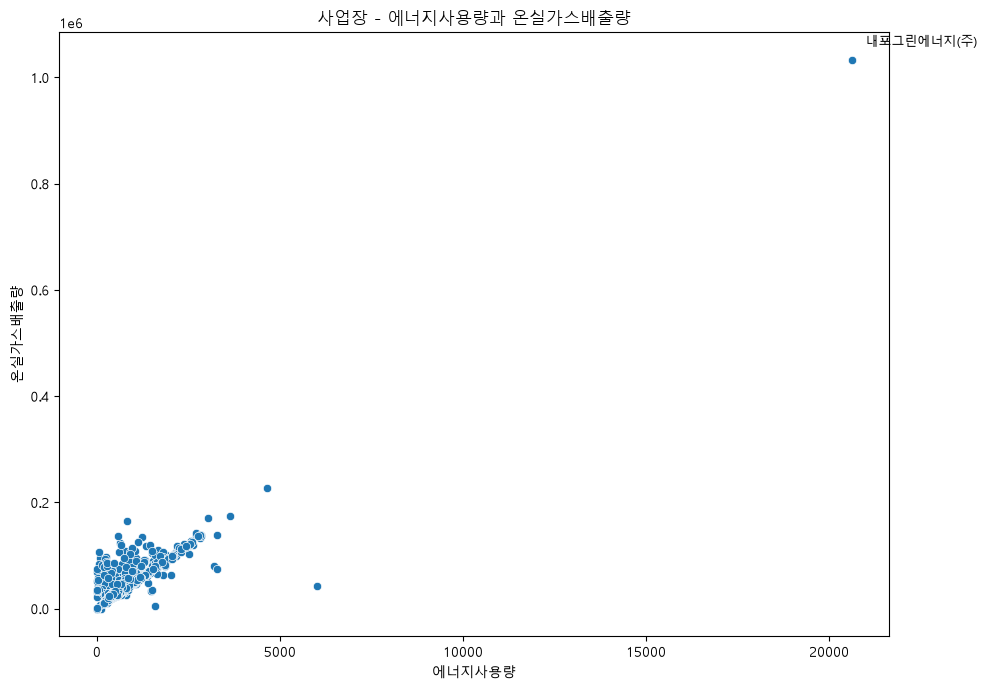

In [63]:
business = df[df['지정구분'] == '사업장'].copy()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=business,
    x='에너지사용량',
    y='온실가스배출량'
)

# 온실가스 배출량 최대 기업
top = business.loc[business['온실가스배출량'].idxmax()]

plt.annotate(
    top['업체명'],
    (top['에너지사용량'], top['온실가스배출량']),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9
)

plt.title('사업장 - 에너지사용량과 온실가스배출량')
plt.xlabel('에너지사용량')
plt.ylabel('온실가스배출량')

plt.tight_layout()
plt.show()

저 하나 압도적으로 에너지사용량 높은 업종: 네포그린에너지...

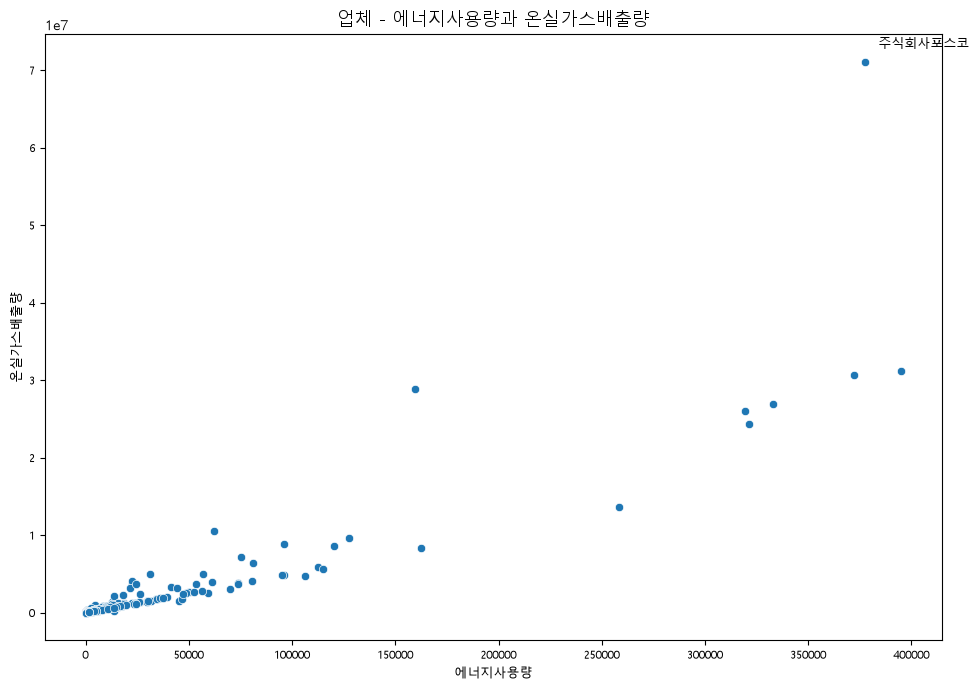

In [61]:
company = df[df['지정구분'] == '업체'].copy()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=company,
    x='에너지사용량',
    y='온실가스배출량'
)

# 온실가스 배출량이 가장 높은 기업
top = company.loc[company['온실가스배출량'].idxmax()]

# 해당 기업 이름 표시
plt.annotate(
    top['업체명'],
    (top['에너지사용량'], top['온실가스배출량']),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9
)

plt.title('업체 - 에너지사용량과 온실가스배출량', fontsize=13)
plt.xlabel('에너지사용량', fontsize=9)
plt.ylabel('온실가스배출량', fontsize=9)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
사업장, 업체 에너지사용량과 온실가스배출량 로그로 보기 

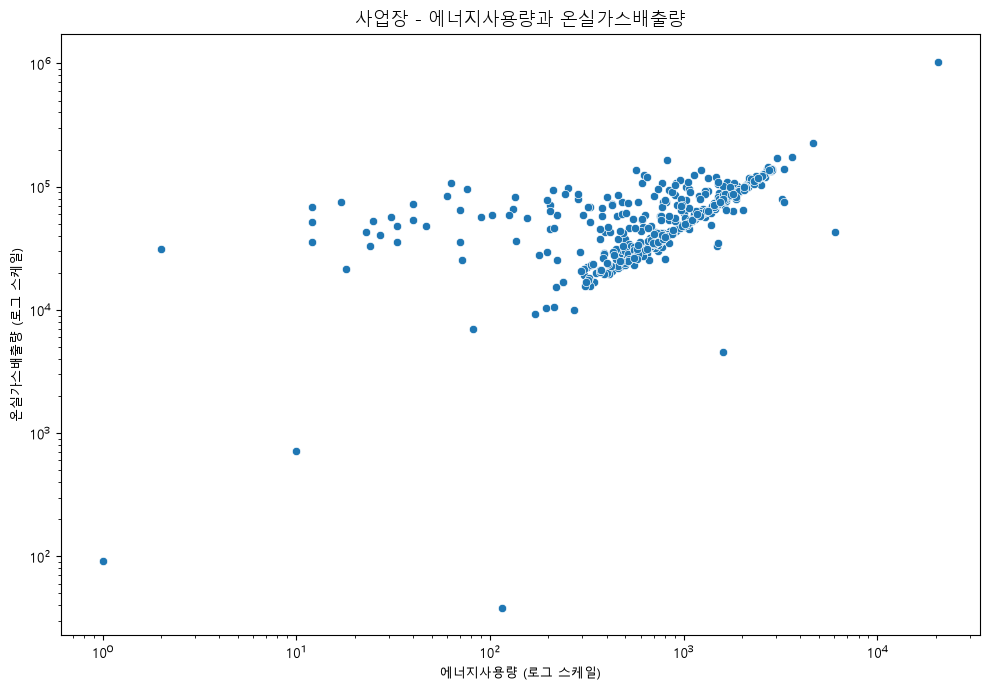

In [62]:
business = df[df['지정구분'] == '사업장']

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=business,
    x='에너지사용량',
    y='온실가스배출량'
)

plt.xscale('log')
plt.yscale('log')

plt.title('사업장 - 에너지사용량과 온실가스배출량', fontsize=13)
plt.xlabel('에너지사용량 (로그 스케일)', fontsize=9)
plt.ylabel('온실가스배출량 (로그 스케일)', fontsize=9)

plt.tight_layout()
plt.show()

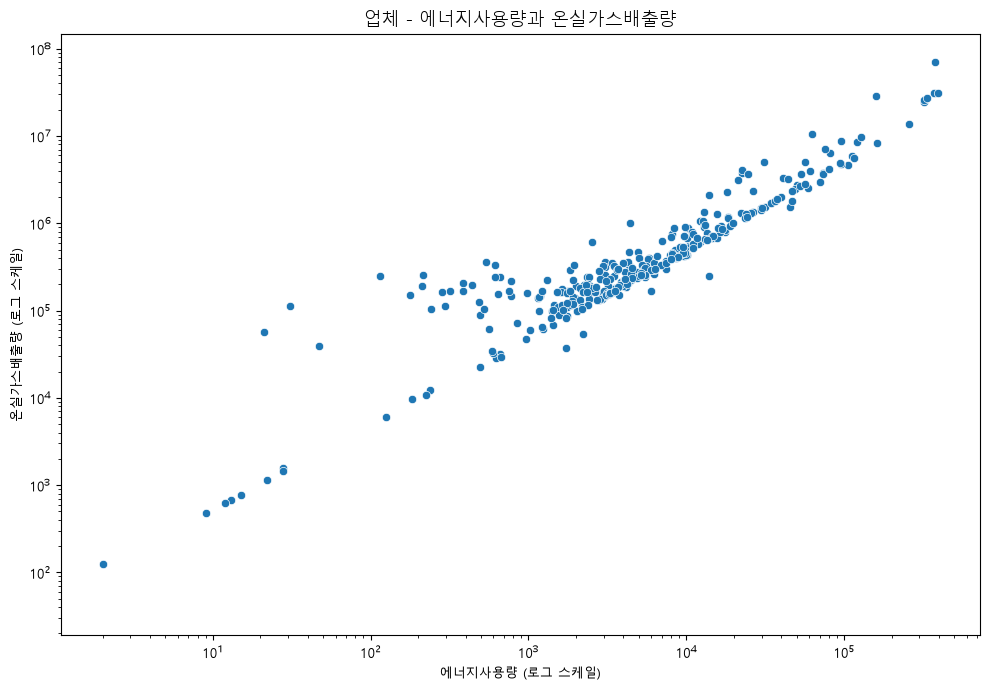

In [59]:
company = df[df['지정구분'] == '업체']

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=company,
    x='에너지사용량',
    y='온실가스배출량'
)

plt.xscale('log')
plt.yscale('log')

plt.title('업체 - 에너지사용량과 온실가스배출량', fontsize=13)
plt.xlabel('에너지사용량 (로그 스케일)', fontsize=9)
plt.ylabel('온실가스배출량 (로그 스케일)', fontsize=9)

plt.tight_layout()
plt.show()

중소기업 Y/N 구분

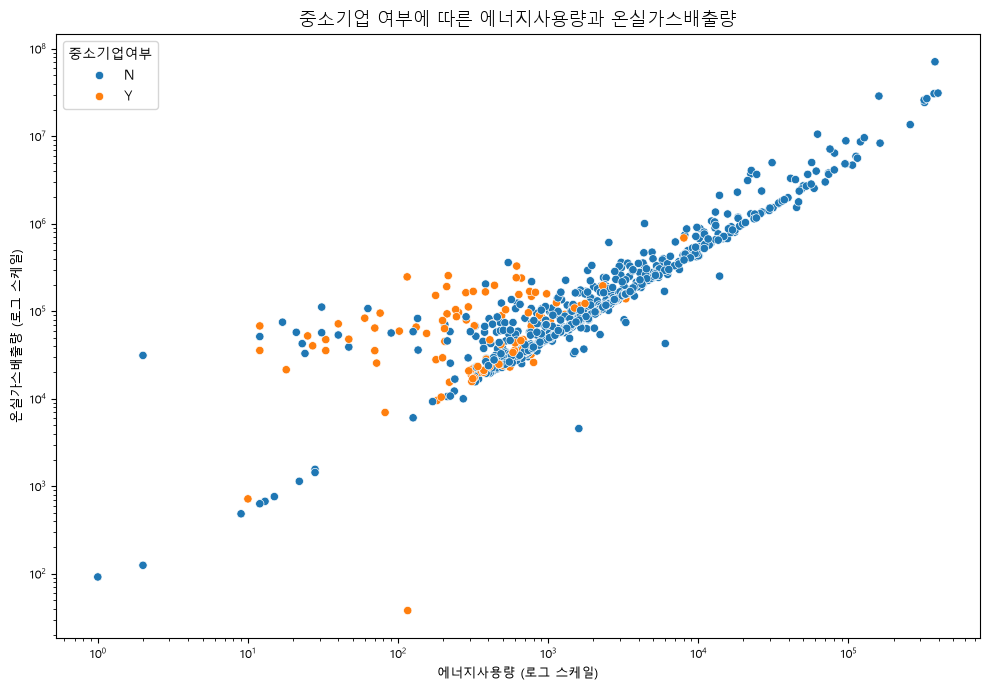

In [64]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='에너지사용량',
    y='온실가스배출량',
    hue='중소기업여부'
)

plt.xscale('log')
plt.yscale('log')

plt.title('중소기업 여부에 따른 에너지사용량과 온실가스배출량', fontsize=13)
plt.xlabel('에너지사용량 (로그 스케일)', fontsize=9)
plt.ylabel('온실가스배출량 (로그 스케일)', fontsize=9)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

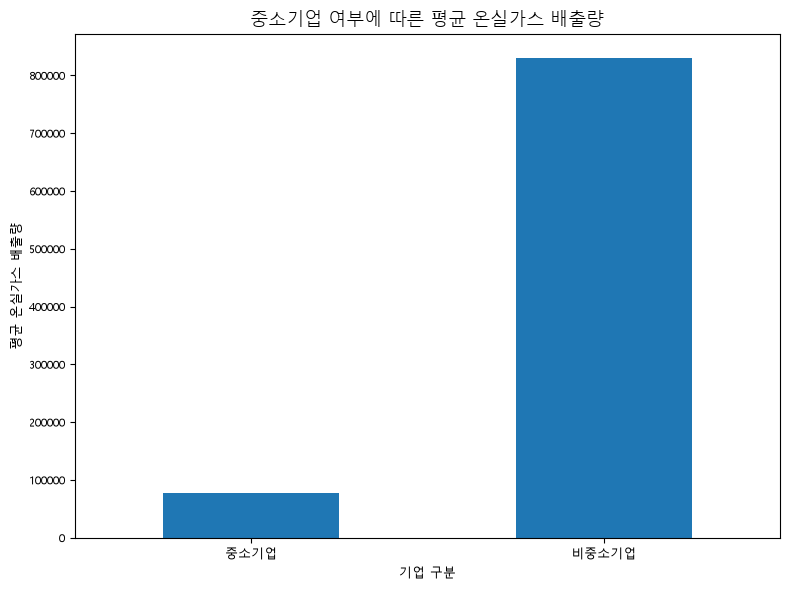

In [65]:
small = df[df['중소기업여부'] == 'Y']
non_small = df[df['중소기업여부'] == 'N']

emission_mean = pd.Series({
    '중소기업': small['온실가스배출량'].mean(),
    '비중소기업': non_small['온실가스배출량'].mean()
})

plt.figure(figsize=(8, 6))

emission_mean.plot(kind='bar')

plt.title('중소기업 여부에 따른 평균 온실가스 배출량', fontsize=13)
plt.xlabel('기업 구분', fontsize=9)
plt.ylabel('평균 온실가스 배출량', fontsize=9)

plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

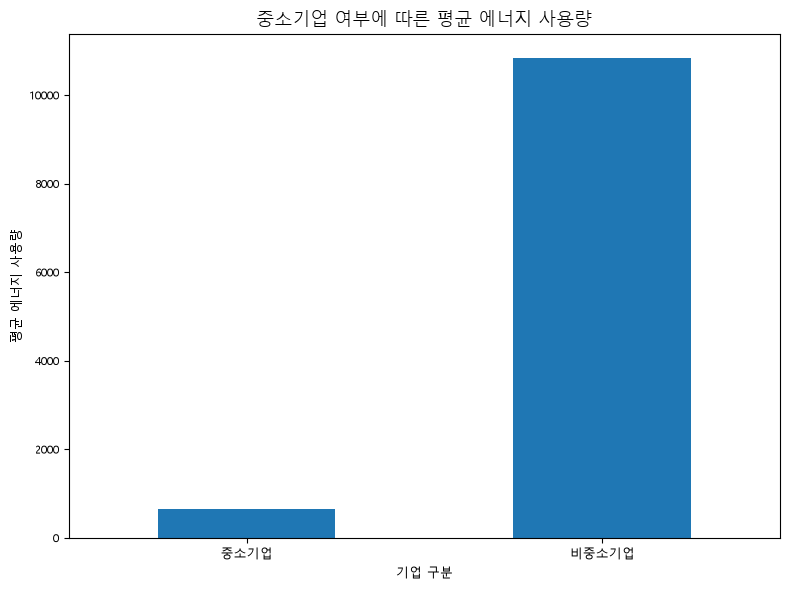

In [66]:
energy_mean = pd.Series({
    '중소기업': small['에너지사용량'].mean(),
    '비중소기업': non_small['에너지사용량'].mean()
})

plt.figure(figsize=(8, 6))

energy_mean.plot(kind='bar')

plt.title('중소기업 여부에 따른 평균 에너지 사용량', fontsize=13)
plt.xlabel('기업 구분', fontsize=9)
plt.ylabel('평균 에너지 사용량', fontsize=9)

plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

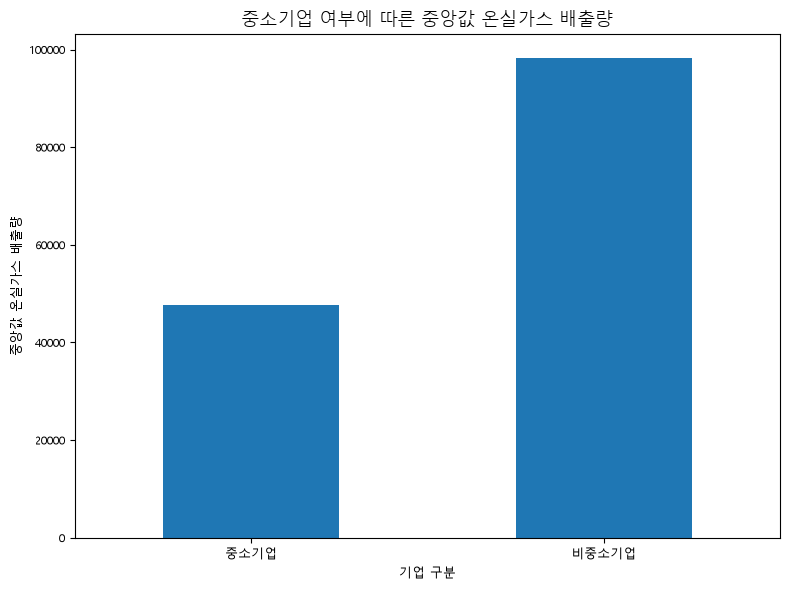

In [67]:
emission_median = pd.Series({
    '중소기업': small['온실가스배출량'].median(),
    '비중소기업': non_small['온실가스배출량'].median()
})

plt.figure(figsize=(8, 6))

emission_median.plot(kind='bar')

plt.title('중소기업 여부에 따른 중앙값 온실가스 배출량', fontsize=13)
plt.xlabel('기업 구분', fontsize=9)
plt.ylabel('중앙값 온실가스 배출량', fontsize=9)

plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

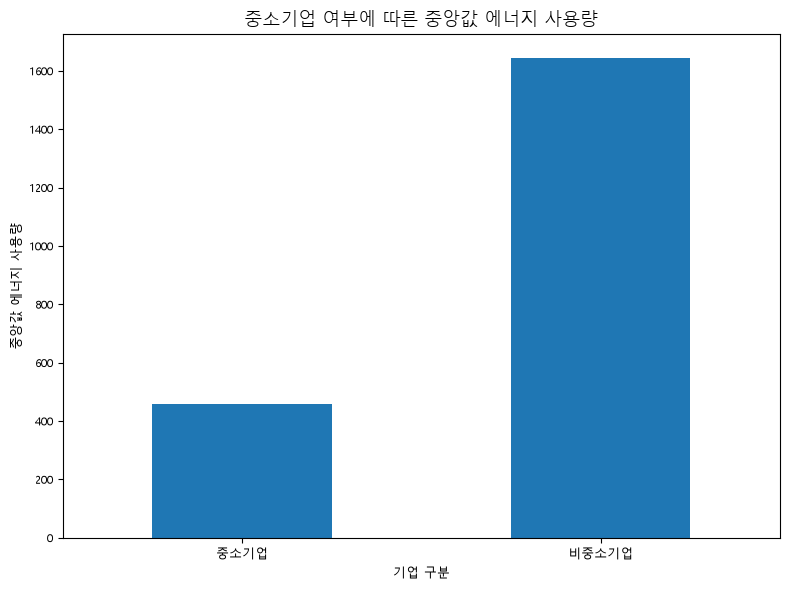

In [68]:
energy_median = pd.Series({
    '중소기업': small['에너지사용량'].median(),
    '비중소기업': non_small['에너지사용량'].median()
})

plt.figure(figsize=(8, 6))

energy_median.plot(kind='bar')

plt.title('중소기업 여부에 따른 중앙값 에너지 사용량', fontsize=13)
plt.xlabel('기업 구분', fontsize=9)
plt.ylabel('중앙값 에너지 사용량', fontsize=9)

plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()